# Problem Sheet 3 — Yang Cheng, yacheng@mpia.de

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import h5py
from scipy.stats import binned_statistic_dd
import illustris_python as il

## 1. Evolution of density contrast on different spatial scales

### 1.1

I use TNG100-3-Dark. First I pick the snapshots closest to z = 11, 5, 2, 0.

In [11]:
basePath = '/home/tnguser/sims.TNG/TNG100-3-Dark/output'

redshifts = np.array([il.groupcat.loadHeader(basePath, snap)['Redshift'] for snap in range(100)])
snaps = [int(np.argmin(np.abs(redshifts - z))) for z in [11, 5, 2, 0]]

for snap in snaps:
    print(f'snap {snap}: z = {redshifts[snap]:.2f}')

#the DM particle mass is only in the snapshot header (MassTable), same as in sheet 1
with h5py.File(basePath + '/snapdir_%03d/snap_%03d.%s.hdf5' % (99, 99, 0), 'r') as f:
    header = dict(f['Header'].attrs)
h = header['HubbleParam']
dm_mass = header['MassTable'][1] * 1e10 / h        # Msun per particle
print(f'Particle mass: {dm_mass:.3e} Msun')

snap 3: z = 10.98
snap 17: z = 5.00
snap 33: z = 2.00
snap 99: z = 0.00
Particle mass: 5.668e+08 Msun


z = 10.98, (physical) box = 9.25 Mpc, (physical) cell = 36 kpc
z = 5.00, (physical) box = 18.47 Mpc, (physical) cell = 72 kpc
z = 2.00, (physical) box = 36.88 Mpc, (physical) cell = 144 kpc
z = 0.00, (physical) box = 110.72 Mpc, (physical) cell = 432 kpc


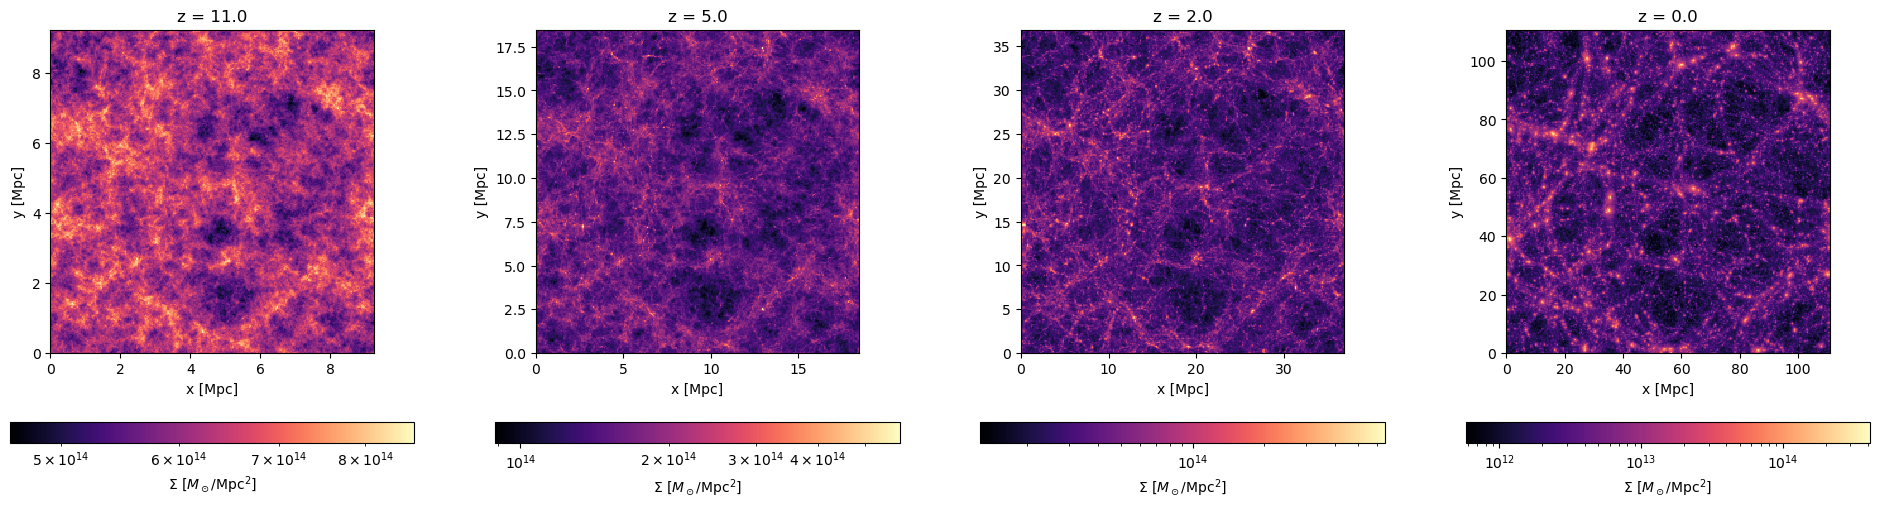

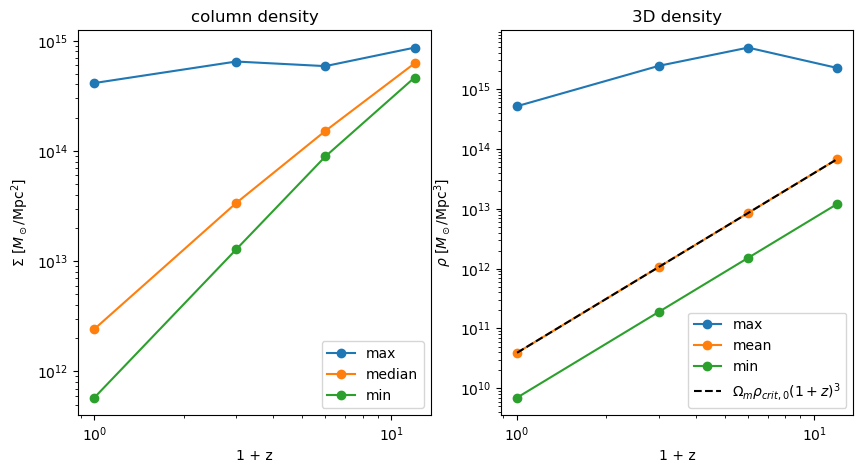

In [24]:
#I manually set the hist bins to 256, for both the 2d and 3d grid
nbins = 256
rho_crit0 = 2.775e11 * h**2                        # Msun/Mpc^3

redshift = []
Sigma_min, Sigma_median, Sigma_max = [], [], []
rho_min, rho_mean, rho_max = [], [], []

fig, axes = plt.subplots(1, len(snaps), figsize=(24, 6))
for ax, snap in zip(axes, snaps):
    header = il.groupcat.loadHeader(basePath, snap)
    a = header['Time']
    z = header['Redshift']
    box = header['BoxSize'] * a / h / 1000         # Mpc

    Coordinates = il.snapshot.loadSubset(basePath, snap, partType=1, fields=['Coordinates']) * a / h / 1000

    pixel_area = (box / nbins)**2
    weights = np.full(len(Coordinates), dm_mass / pixel_area)
    Sigma, xedges, yedges, image = ax.hist2d(x=Coordinates[:, 0], y=Coordinates[:, 1], weights=weights,
        bins=nbins, range=[[0, box], [0, box]], norm=mpl.colors.LogNorm(), cmap='magma')
    ax.set(xlabel='x [Mpc]', ylabel='y [Mpc]', title=f'z = {z:.1f}')
    ax.set_aspect('equal')
    fig.colorbar(image, ax=ax, label=r'$\Sigma$ [$M_\odot$/Mpc$^2$]', location='bottom')

    counts = binned_statistic_dd(Coordinates, np.arange(len(Coordinates)), bins=nbins,
        range=[[0, box]] * 3, statistic='count')[0]
    rho = counts * dm_mass / (box / nbins)**3

    redshift.append(z)
    Sigma_min.append(Sigma[Sigma > 0].min())
    Sigma_median.append(np.median(Sigma))
    Sigma_max.append(Sigma.max())
    rho_min.append(rho[rho > 0].min())
    rho_mean.append(rho.mean())
    rho_max.append(rho.max())
    print(f'z = {z:.2f}, (physical) box = {box:.2f} Mpc, (physical) cell = {box / nbins * 1000:.0f} kpc')
plt.show()

redshift = np.array(redshift)
z_plot = np.linspace(0, redshift.max(), 100)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].plot(1 + redshift, Sigma_max, marker='o', label='max')
axes[0].plot(1 + redshift, Sigma_median, marker='o', label='median')
axes[0].plot(1 + redshift, Sigma_min, marker='o', label='min')
axes[0].set(ylabel=r'$\Sigma$ [$M_\odot$/Mpc$^2$]', title='column density')

axes[1].plot(1 + redshift, rho_max, marker='o', label='max')
axes[1].plot(1 + redshift, rho_mean, marker='o', label='mean')
axes[1].plot(1 + redshift, rho_min, marker='o', label='min')
axes[1].plot(1 + z_plot, header['Omega0'] * rho_crit0 * (1 + z_plot)**3, 'k--',
             label=r'$\Omega_m\rho_{crit,0}(1+z)^3$')
axes[1].set(ylabel=r'$\rho$ [$M_\odot$/Mpc$^3$]', title='3D density')

for ax in axes:
    ax.set(xscale='log', yscale='log', xlabel='1 + z')
    ax.legend()
plt.show()

### 1.1 discussion

At high z the maps are almost uniform, and going to z=0 the matter collapses into filaments and haloes with big voids in between, so the range of densities gets much wider. The mean density of the box is just total mass over physical volume, so it goes like $(1+z)^3$, and it agrees with $\Omega_m\rho_{crit,0}(1+z)^3$ (the total mass is conserved, only the physical volume changes).

### 1.2

$\delta = (\rho - \bar\rho)/\bar\rho$, measured on 3D cubes of 10 Mpc, 1 Mpc and 100 kpc at z=0, using `binned_statistic_dd` as in the input notebook. For 100 kpc the full box would need $1107^3$ cells, which doesn't fit in memory, so there I only take a 20 Mpc sub-cube with all the particles.

10 Mpc: max delta = 19.4, empty cells = 0.0%
1 Mpc: max delta = 2697.8, empty cells = 16.7%
0.1 Mpc: max delta = 32158.4, empty cells = 97.8%


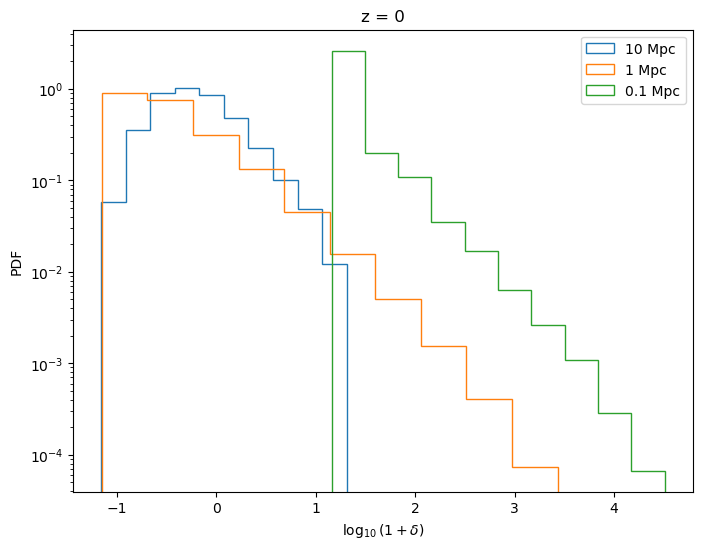

In [29]:
snap = 99
header = il.groupcat.loadHeader(basePath, snap)
a = header['Time']
box = header['BoxSize'] * a / h / 1000             # Mpc

Coordinates = il.snapshot.loadSubset(basePath, snap, partType=1, fields=['Coordinates']) * a / h / 1000
rho_avg = len(Coordinates) * dm_mass / box**3

def density_contrast(Coordinates, box, nbins, mass, rho_avg):
    counts = binned_statistic_dd(Coordinates, np.arange(len(Coordinates)), bins=nbins,
        range=[[0, box]] * 3, statistic='count')[0].flatten()
    rho = counts * mass / (box / nbins)**3
    return rho / rho_avg - 1

deltas = {}
for cell, n_downsample in [(10, 100), (1, 5)]:
    deltas[cell] = density_contrast(Coordinates[rng.random(len(Coordinates)) < 1 / n_downsample], box, int(box / cell),
                                    dm_mass * n_downsample, rho_avg)

sub = 20 # for 100 kpc I manually use a subbox to compute bcs the memory exceeded 10GB for the entire box
inside = np.all(Coordinates < sub, axis=1)
deltas[0.1] = density_contrast(Coordinates[inside], sub, int(sub / 0.1), dm_mass, rho_avg)

fig, ax = plt.subplots(figsize=(8, 6))
for cell, delta in deltas.items():
    ax.hist(np.log10(1 + delta[delta > -1]), density=True, histtype='step', label=f'{cell} Mpc')
    print(f'{cell} Mpc: max delta = {delta.max():.1f}, empty cells = {np.mean(delta == -1):.1%}')
ax.set(xlabel=r'$\log_{10}(1+\delta)$', ylabel='PDF', yscale='log', title='z = 0')
ax.legend()
plt.show()

### 1.2 discussion

The PDF is asymmetric for all cube sizes: $\delta$ reaches $-1$ (rho = 0) with a long tail to high values. From 0.1 mpc to 10 mpc, I can see that the smaller the 'smoothing' scale gives a wider the PDF and the higher the maximum $\delta$. This makes sense because a small window covers smaller structures which can cover only higher density areas while a larger window averages high density regions with void. The 100 kpc histogram starts at around log(1+sigma) >1, I assume this is where the window gets so small that it captures the case where only one particles enters the window and the majority of the window measurements are empty.

### 1.3

Same function at z ≈ 11, 10, 5, 2, 0. I keep the same comoving cell size (65 cells per side, i.e. 7 lattice cells or 1.7 cMpc) at all redshifts, so the same material is compared.

z = 11.0: (physical) cell = 185 kpc, max delta = 2.5, empty cells = 0.0%
z = 10.0: (physical) cell = 201 kpc, max delta = 2.9, empty cells = 0.0%
z = 5.0: (physical) cell = 369 kpc, max delta = 11.6, empty cells = 0.0%
z = 2.0: (physical) cell = 738 kpc, max delta = 90.5, empty cells = 0.0%
z = 0.0: (physical) cell = 2214 kpc, max delta = 586.9, empty cells = 0.0%


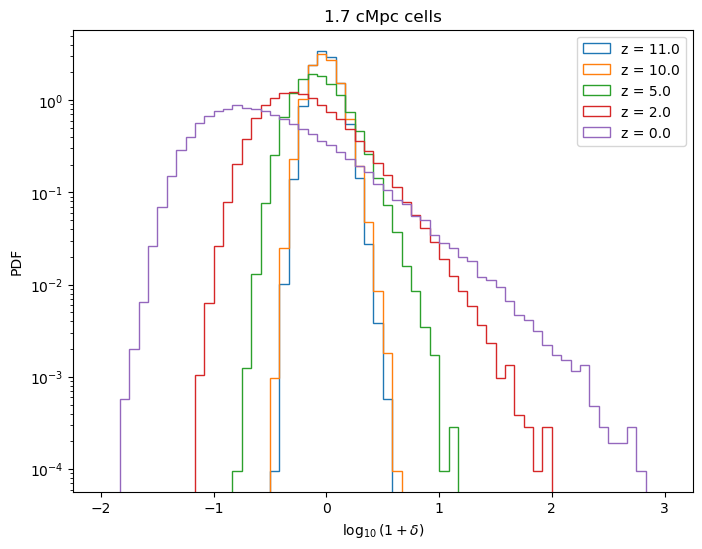

In [32]:
nbins = 50 #it's a manually set values
snaps_13 = [int(np.argmin(np.abs(redshifts - z))) for z in [11, 10, 5, 2, 0]]

fig, ax = plt.subplots(figsize=(8, 6))
for snap in snaps_13:
    header = il.groupcat.loadHeader(basePath, snap)
    a = header['Time']
    z = header['Redshift']
    box = header['BoxSize'] * a / h / 1000         # Mpc

    Coordinates = il.snapshot.loadSubset(basePath, snap, partType=1, fields=['Coordinates']) * a / h / 1000
    rho_avg = len(Coordinates) * dm_mass / box**3

    delta = density_contrast(Coordinates, box, nbins, dm_mass, rho_avg)
    ax.hist(np.log10(1 + delta[delta > -1]), bins=np.linspace(-2, 3, 61), density=True,
            histtype='step', label=f'z = {z:.1f}')
    print(f'z = {z:.1f}: (physical) cell = {box / nbins * 1000:.0f} kpc, max delta = {delta.max():.1f}, '
          f'empty cells = {np.mean(delta == -1):.1%}')
ax.set(xlabel=r'$\log_{10}(1+\delta)$', ylabel='PDF', yscale='log', title='1.7 cMpc cells')
ax.legend()
plt.show()


#### 1.3 discussion

At z > 10 the PDF is a narrow peak around $\delta = 0$, the matter is still almost uniform and the distrbution is quite symmetric. With time gravity makes overdense regions denser and underdense ones emptier, so the PDF gets wider on both sides and the high-density tail grows.

### 1.4

TNG100-3-Dark vs TNG300-3-Dark at z=0, both with 3 Mpc cells. TNG300 has a lower resolution, so I need bigger cells to have enough particles per cell.

TNG100-3-Dark: box = 110.7 Mpc, cell = 3.08 Mpc, max delta = 357.9
TNG300-3-Dark: box = 302.6 Mpc, cell = 3.03 Mpc, max delta = 631.5


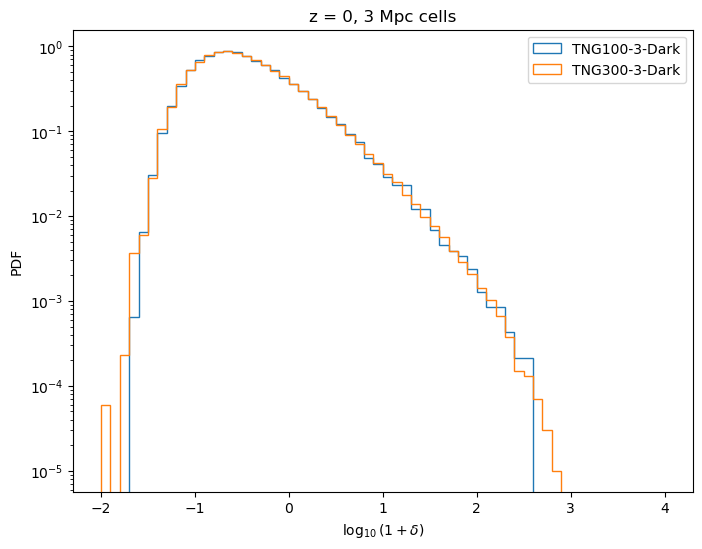

In [33]:
cell = 3                                           # Mpc
sims = [('TNG100-3-Dark', basePath),
        ('TNG300-3-Dark', '/home/tnguser/sims.TNG/TNG300-3-Dark/output')]

fig, ax = plt.subplots(figsize=(8, 6))
for name, path in sims:
    with h5py.File(path + '/snapdir_%03d/snap_%03d.%s.hdf5' % (99, 99, 0), 'r') as f:
        header = dict(f['Header'].attrs)
    box = header['BoxSize'] / h / 1000             # Mpc, a = 1
    mass = header['MassTable'][1] * 1e10 / h       # Msun per particle
    nbins = int(box / cell)

    #TNG300 has 625^3 particles, too many to bin at once, so I read and bin one file chunk at a time
    counts = np.zeros((nbins, nbins, nbins))
    for num in range(header['NumFilesPerSnapshot']):
        with h5py.File(path + '/snapdir_%03d/snap_%03d.%s.hdf5' % (99, 99, num), 'r') as f:
            Coordinates = np.array(f['PartType1']['Coordinates'][:]) / h / 1000
        counts += binned_statistic_dd(Coordinates, np.arange(len(Coordinates)), bins=nbins,
            range=[[0, box]] * 3, statistic='count')[0]

    rho = counts.flatten() * mass / (box / nbins)**3
    rho_avg = counts.sum() * mass / box**3
    delta = rho / rho_avg - 1

    ax.hist(np.log10(1 + delta[delta > -1]), bins=np.linspace(-2, 4, 61), density=True,
            histtype='step', label=name)
    print(f'{name}: box = {box:.1f} Mpc, cell = {box / nbins:.2f} Mpc, max delta = {delta.max():.1f}')
ax.set(xlabel=r'$\log_{10}(1+\delta)$', ylabel='PDF', yscale='log', title=f'z = 0, {cell} Mpc cells')
ax.legend()
plt.show()


### 1.4 discussion

In general the two PDFs agrees with the same smoothing scale, but TNG300 extends maybe a bit in both high and low end. I think this may originate from the fact that the TNG300 samples a more complete distribution.

## 2. Gravitational collapse and the formation of haloes

### 2.1

Cluster with $M = 10^{15}\,M_\odot$ inside $R = 2$ Mpc, compared to the mean matter density today $\bar\rho = \Omega_m\rho_{crit,0}$, with $\rho_{crit,0} = 2.775\times10^{11}h^2\,M_\odot/\mathrm{Mpc}^3$ and the TNG cosmology.

In [34]:
M_cluster = 1e15                                   # Msun
R_cluster = 2                                      # Mpc
rho_cluster = M_cluster / (4 / 3 * np.pi * R_cluster**3)

Om0 = 0.3089
rho_mean = Om0 * 2.775e11 * h**2                   # Msun/Mpc^3

delta_cluster = rho_cluster / rho_mean - 1
print(f'rho_cluster = {rho_cluster:.3e} Msun/Mpc^3')
print(f'rho_mean    = {rho_mean:.3e} Msun/Mpc^3')
print(f'delta = {delta_cluster:.0f}, log10(1+delta) = {np.log10(1 + delta_cluster):.2f}')

rho_cluster = 2.984e+13 Msun/Mpc^3
rho_mean    = 3.933e+10 Msun/Mpc^3
delta = 758, log10(1+delta) = 2.88


### 2.1 discussion

$\delta \approx 760$, i.e. $\log_{10}(1+\delta) \approx 2.9$. On similar scales (1–3 Mpc cells) this is at the very end of the tails of the PDFs in 1.2 and 1.4, so such clusters are very rare objects.

## 3. The distribution of material within dark-matter haloes

### 3.1

For the halo profiles I use TNG50-4-Dark. Radial bins are log-spaced from $0.03R_{200c}$ to $R_{200c}$.

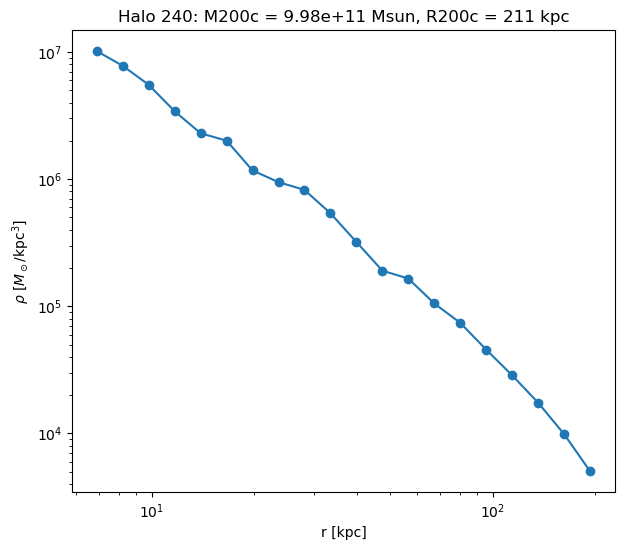

In [35]:
basePath_50 = '/home/tnguser/sims.TNG/TNG50-4-Dark/output'
snap = 99

with h5py.File(basePath_50 + '/snapdir_%03d/snap_%03d.%s.hdf5' % (snap, snap, 0), 'r') as f:
    header = dict(f['Header'].attrs)
a = header['Time']
box = header['BoxSize']                            # ckpc/h, for the periodic wrap
pmass = header['MassTable'][1] * 1e10 / h          # Msun per particle

halos = il.groupcat.loadHalos(basePath_50, snap, fields=['GroupPos', 'Group_M_Crit200', 'Group_R_Crit200'])
M200c = halos['Group_M_Crit200'] * 1e10 / h        # Msun
R200c = halos['Group_R_Crit200'] * a / h           # kpc

def distances(Coordinates, GroupPos, BoxSize):
    d = Coordinates - GroupPos
    d = (d + BoxSize / 2) % BoxSize - BoxSize / 2  # periodic box
    return np.linalg.norm(d, axis=1) * a / h       # kpc

def density_profile(haloID, n_bins=20):
    Coordinates = il.snapshot.loadHalo(basePath_50, snap, haloID, partType=1, fields=['Coordinates'])
    r = distances(Coordinates, halos['GroupPos'][haloID], box)
    bins = np.logspace(np.log10(0.03 * R200c[haloID]), np.log10(R200c[haloID]), n_bins + 1)
    mass = np.histogram(r, bins=bins)[0] * pmass
    volume = 4 / 3 * np.pi * (bins[1:]**3 - bins[:-1]**3)
    return np.sqrt(bins[1:] * bins[:-1]), mass / volume #this is the final profile over distance

haloID = int(np.argmin(np.abs(M200c - 1e12)))
r, rho = density_profile(haloID)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(r, rho, marker='o')
ax.set(xscale='log', yscale='log', xlabel='r [kpc]', ylabel=r'$\rho$ [$M_\odot$/kpc$^3$]',
       title=f'Halo {haloID}: M200c = {M200c[haloID]:.2e} Msun, R200c = {R200c[haloID]:.0f} kpc')
plt.show()

### 3.2

Mass bins of 0.2 dex around $10^{11}$, $10^{12}$ and $10^{13}\,M_\odot$ (at most 50 haloes per bin), mean profile per bin, vs $r$ and vs $r/R_{200c}$. Since the bins go from $0.03R_{200c}$ to $R_{200c}$ for every halo, the $r/R_{200c}$ grid is the same for all of them.

M200c ~ 1e+11: N = 50, rho at 3.3 kpc = 6.43e+06 Msun/kpc^3
M200c ~ 1e+12: N = 50, rho at 7.0 kpc = 8.28e+06 Msun/kpc^3
M200c ~ 1e+13: N = 6, rho at 14.6 kpc = 7.79e+06 Msun/kpc^3


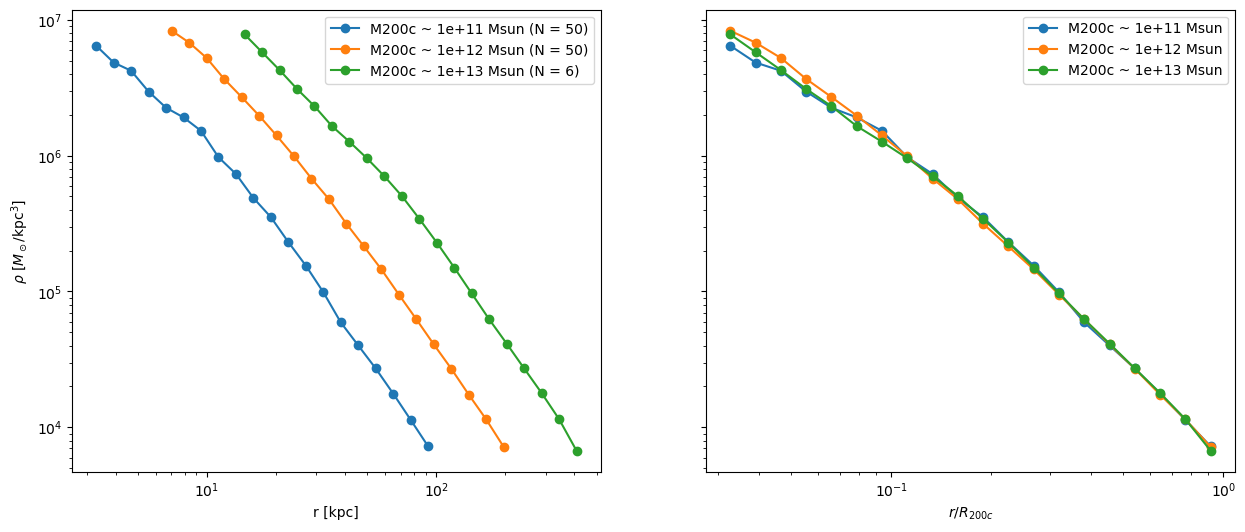

In [37]:
mass_bins = [1e11, 1e12, 1e13]

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
for M in mass_bins:
    #0.2 dex bin width so assume +- 0.1 on log values
    select = np.where((M200c > M * 10**-0.1) & (M200c < M * 10**0.1))[0][:50] 
    profiles = [density_profile(i) for i in select] # iterate over all selected halos
    r_mean = np.mean([p[0] for p in profiles], axis=0)
    rho_mean = np.mean([p[1] for p in profiles], axis=0)
    x = profiles[0][0] / R200c[select[0]]

    axes[0].plot(r_mean, rho_mean, marker='o', label=f'M200c ~ {M:.0e} Msun (N = {len(select)})')
    axes[1].plot(x, rho_mean, marker='o', label=f'M200c ~ {M:.0e} Msun')
    print(f'M200c ~ {M:.0e}: N = {len(select)}, rho at {r_mean[0]:.1f} kpc = {rho_mean[0]:.2e} Msun/kpc^3')

axes[0].set(xscale='log', yscale='log', xlabel='r [kpc]', ylabel=r'$\rho$ [$M_\odot$/kpc$^3$]')
axes[1].set(xscale='log', xlabel=r'$r/R_{200c}$')
for ax in axes:
    ax.legend()
plt.show()

### 3.2 discussion

In physical radius, more massive haloes are bigger and reach higher densities at the same $r$. If normalized by $r/R_{200c}$ the three profiles overlaps, i.e. despite different total mass, their shape of mass distribution is similar.

### 3.3

 Fit density profile for Navarro-Frenk-White formula and Einasto formula:

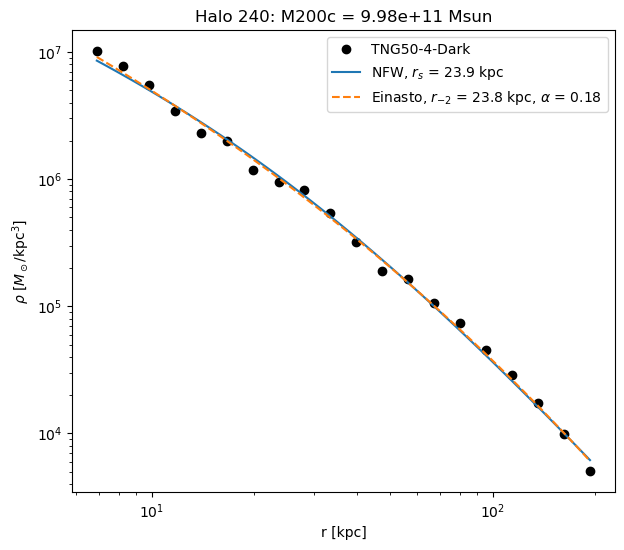

NFW $r_s$: r ~ M200c^0.33
Einasto $r_{-2}$: r ~ M200c^0.28


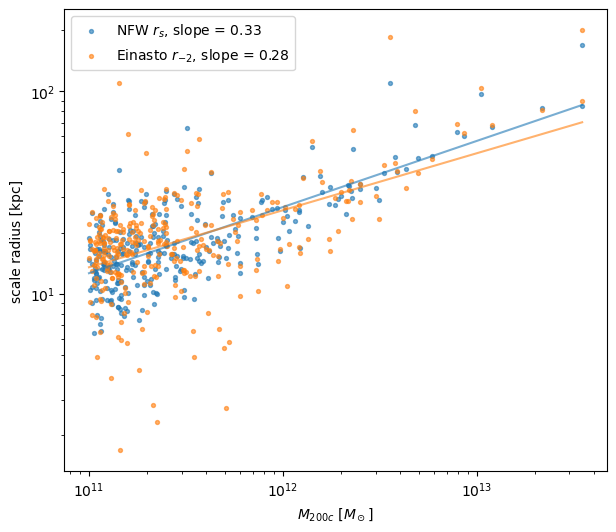

Einasto alpha: median = 0.23


In [40]:
from scipy.optimize import curve_fit

def density_profile(haloID, n_bins=20):
    Coordinates = il.snapshot.loadHalo(basePath_50, snap, haloID, partType=1, fields=['Coordinates'])
    r = distances(Coordinates, halos['GroupPos'][haloID], box)
    bins = np.logspace(np.log10(0.03 * R200c[haloID]), np.log10(R200c[haloID]), n_bins + 1)
    mass = np.histogram(r, bins=bins)[0] * pmass
    volume = 4 / 3 * np.pi * (bins[1:]**3 - bins[:-1]**3)
    return np.sqrt(bins[1:] * bins[:-1]), mass / volume

def log_NFW(r, rs, log_rho0):
    x = r / rs
    return log_rho0 - np.log10(x * (1 + x)**2)

def log_Einasto(r, r2, log_rho2, alpha):
    return log_rho2 - 2 / alpha * ((r / r2)**alpha - 1) / np.log(10)

def fit_profiles(haloID):
    r, rho = density_profile(haloID)
    good = rho > 0
    R = R200c[haloID]
    p_nfw = curve_fit(log_NFW, r[good], np.log10(rho[good]), p0=[R / 5, 7],
                      bounds=([0.01 * R, 0], [R, 12]))[0]
    p_ein = curve_fit(log_Einasto, r[good], np.log10(rho[good]), p0=[R / 5, 6, 0.17],
                      bounds=([0.01 * R, 0, 0.05], [R, 12, 1]))[0]
    return r, rho, p_nfw, p_ein

#example: the halo from 3.1
r, rho, p_nfw, p_ein = fit_profiles(haloID)
r_plot = np.logspace(np.log10(r[0]), np.log10(r[-1]), 100)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(r, rho, 'o', color='black', label='TNG50-4-Dark')
ax.plot(r_plot, 10**log_NFW(r_plot, *p_nfw), label=f'NFW, $r_s$ = {p_nfw[0]:.1f} kpc')
ax.plot(r_plot, 10**log_Einasto(r_plot, *p_ein), '--',
        label=f'Einasto, $r_{{-2}}$ = {p_ein[0]:.1f} kpc, $\\alpha$ = {p_ein[2]:.2f}')
ax.set(xscale='log', yscale='log', xlabel='r [kpc]', ylabel=r'$\rho$ [$M_\odot$/kpc$^3$]',
       title=f'Halo {haloID}: M200c = {M200c[haloID]:.2e} Msun')
ax.legend()
plt.show()

#many haloes
rng = np.random.default_rng(0)
sample = np.where(M200c > 1e11)[0]
sample = rng.choice(sample, size=min(300, len(sample)), replace=False)

rs_nfw, r2_ein, alpha_ein = [], [], []
for i in sample:
    r, rho, p_nfw, p_ein = fit_profiles(i)
    rs_nfw.append(p_nfw[0])
    r2_ein.append(p_ein[0])
    alpha_ein.append(p_ein[2])
rs_nfw, r2_ein, alpha_ein = np.array(rs_nfw), np.array(r2_ein), np.array(alpha_ein)

M_plot = np.logspace(11, np.log10(M200c[sample].max()), 100)
fig, ax = plt.subplots(figsize=(7, 6))
for rs, label in zip([rs_nfw, r2_ein], [r'NFW $r_s$', r'Einasto $r_{-2}$']):
    slope, offset = np.polyfit(np.log10(M200c[sample]), np.log10(rs), 1)
    points = ax.scatter(M200c[sample], rs, s=8, alpha=0.6, label=f'{label}, slope = {slope:.2f}')
    ax.plot(M_plot, 10**offset * M_plot**slope, color=points.get_facecolor()[0])
    print(f'{label}: r ~ M200c^{slope:.2f}')
ax.set(xscale='log', yscale='log', xlabel=r'$M_{200c}$ [$M_\odot$]', ylabel='scale radius [kpc]')
ax.legend()
plt.show()

print(f'Einasto alpha: median = {np.median(alpha_ein):.2f}')


### 3.3 discussion

$r_s$ grows with halo mass roughly as a power law, but it fits badly especially at low mass end. $R_{200c} \propto M_{200c}^{1/3}$.

## 4. Build your own Python Cosmological Calculator (Part II)

Growth factor with the Carroll+1992 fitting formula:

$g(\Omega_m,\Omega_\Lambda) = \dfrac{5}{2}\Omega_m \Big/ \left[\Omega_m^{4/7} - \Omega_\Lambda + \left(1+\dfrac{\Omega_m}{2}\right)\left(1+\dfrac{\Omega_\Lambda}{70}\right)\right]$

$D_+(z) = \dfrac{1}{1+z}\,\dfrac{g(\Omega_m(z),\Omega_\Lambda(z))}{g(\Omega_{m,0},\Omega_{\Lambda,0})}$

with $\Omega_m(z)$, $\Omega_\Lambda(z)$ from $E(z)$ as in Problem Sheet 2, so that $D_+(0) = 1$.

The following code follows the same name convention in homework1 /

In [42]:
def E(z, Om, Or, OL):
    Ok = 1 - Om - Or - OL
    return np.sqrt(Or*(1+z)**4 + Om*(1+z)**3 + Ok*(1+z)**2 + OL)

def g_carroll(Om, OL):
    return 2.5*Om / (Om**(4/7) - OL + (1+Om/2)*(1+OL/70))

def D_plus(z, Om, Or, OL):
    Omz = Om*(1+z)**3 / E(z, Om, Or, OL)**2
    OLz = OL / E(z, Om, Or, OL)**2
    return g_carroll(Omz, OLz) / g_carroll(Om, OL) / (1+z)

print('EdS D+(z=1) =', D_plus(1, 1, 0, 0))

EdS D+(z=1) = 0.4999999999999999


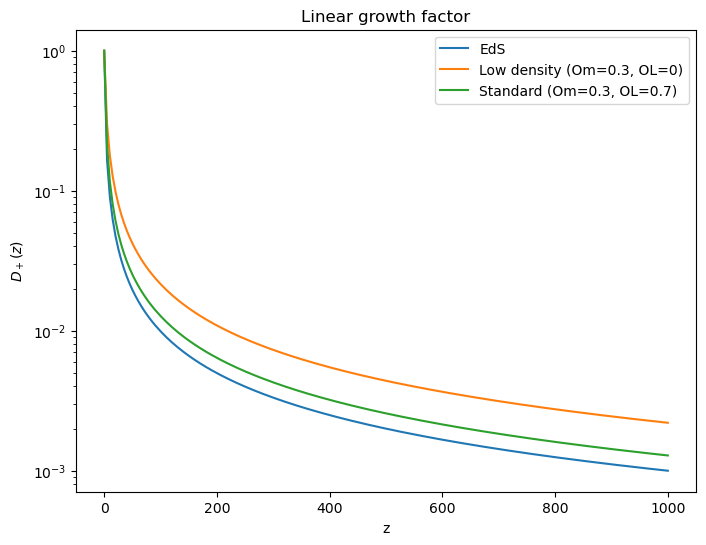

In [44]:
z = np.linspace(0, 1000, 200)
models = {
    'EdS':                          (1.0, 0, 0),
    'Low density (Om=0.3, OL=0)':   (0.3, 0, 0),
    'Standard (Om=0.3, OL=0.7)':    (0.3, 0, 0.7),
}

fig, ax = plt.subplots(figsize=(8, 6))
for name, (Om, Or, OL) in models.items():
    ax.plot(z, D_plus(z, Om, Or, OL), label=name)
ax.set(xlabel='z', ylabel=r'$D_+(z)$', yscale='log', title='Linear growth factor')
ax.legend()
plt.show()

### 4 discussion

All three models have $D_+(0) = 1$ by construction. For EdS $D_+ = 1/(1+z)$ exactly, while the low-density and the standard model has a more supressed growth factor at high z. At high z, $\Omega_m(z) \to 1$ in all models, so the curves follow $(1+z)^{-1}$ as expected.